In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [3]:
df = pd.read_csv("lab2 machine learning/data.csv")

# Display first 5 rows
df.head(7)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0
5,32,0,2,105,198,0,0,165,0,0.0,?,?,?,0
6,32,1,2,110,225,0,0,184,0,0.0,?,?,?,0


In [7]:
# viewing the data types of columns
df.dtypes

age             int64
sex             int64
cp              int64
trestbps       object
chol           object
fbs            object
restecg        object
thalach        object
exang          object
oldpeak       float64
slope          object
ca             object
thal           object
num             int64
dtype: object

In [11]:
# Columns that should be numeric but are stored as object
cols_to_convert = [
    'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'slope', 'ca', 'thal'
]

# Check updated data types
print(df.dtypes)


age             int64
sex             int64
cp              int64
trestbps      float64
chol          float64
fbs           float64
restecg       float64
thalach       float64
exang         float64
oldpeak       float64
slope         float64
ca            float64
thal          float64
num             int64
dtype: object


In [14]:
#check for missing values
print(df.isna().sum())

age             0
sex             0
cp              0
trestbps        1
chol           23
fbs             8
restecg         1
thalach         1
exang           1
oldpeak         0
slope         190
ca            291
thal          266
num             0
dtype: int64


In [13]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

102    True
dtype: bool

In [15]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (294, 14) 

number of rows:  294
number of columns:  14


In [16]:
# Statistical summary
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,294.000000,294.000000,294.000000,293.000000,271.000000,286.000000,293.000000,293.000000,293.000000,294.000000,104.000000,3.0,28.000000,294.000000
mean,47.826531,0.724490,2.982993,132.583618,250.848708,0.069930,0.218430,139.129693,0.303754,0.586054,1.894231,0.0,5.642857,0.360544
std,7.811812,0.447533,0.965117,17.626568,67.657711,0.255476,0.460868,23.589749,0.460665,0.908648,0.338995,0.0,1.615074,0.480977
min,28.000000,0.000000,1.000000,92.000000,85.000000,0.000000,0.000000,82.000000,0.000000,0.000000,1.000000,0.0,3.000000,0.000000
25%,42.000000,0.000000,2.000000,120.000000,209.000000,0.000000,0.000000,122.000000,0.000000,0.000000,2.000000,0.0,5.250000,0.000000
50%,49.000000,1.000000,3.000000,130.000000,243.000000,0.000000,0.000000,140.000000,0.000000,0.000000,2.000000,0.0,6.000000,0.000000
75%,54.000000,1.000000,4.000000,140.000000,282.500000,0.000000,0.000000,155.000000,1.000000,1.000000,2.000000,0.0,7.000000,1.000000
max,66.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,190.000000,1.000000,5.000000,3.000000,0.0,7.000000,1.000000


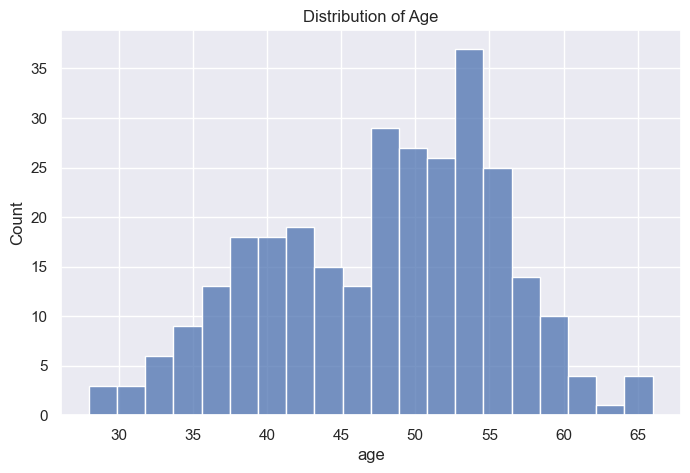

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20)
plt.title("Distribution of Age")
plt.show()

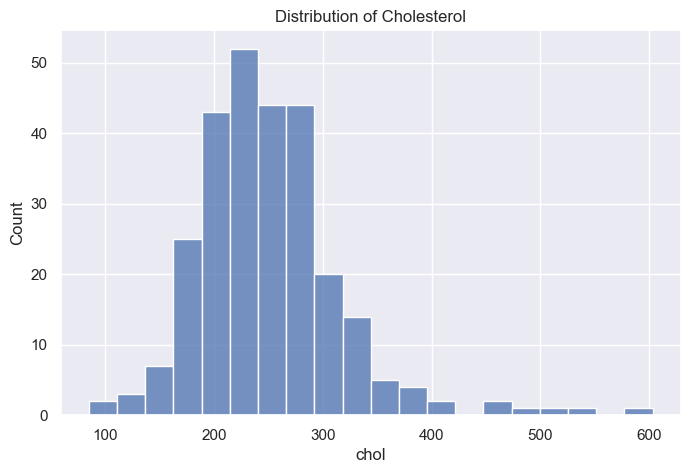

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['chol'], bins=20)
plt.title("Distribution of Cholesterol")
plt.show()

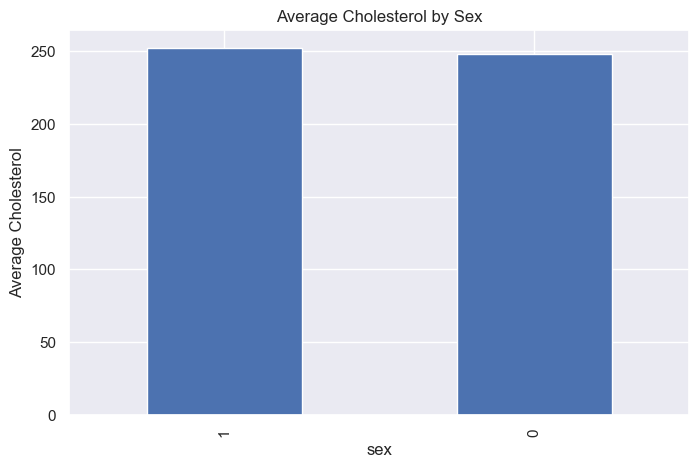

sex
1    252.040609
0    247.675676
Name: chol, dtype: float64

In [21]:
chol_by_sex = df.groupby('sex')['chol'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
chol_by_sex.plot(kind='bar')
plt.title("Average Cholesterol by Sex")
plt.ylabel("Average Cholesterol")
plt.show()

chol_by_sex

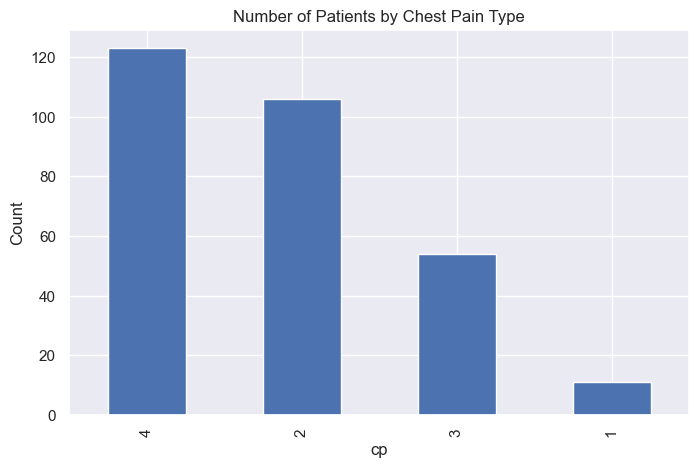

cp
4    123
2    106
3     54
1     11
dtype: int64

In [22]:
cp_count = df.groupby('cp').size().sort_values(ascending=False)

plt.figure(figsize=(8,5))
cp_count.plot(kind='bar')
plt.title("Number of Patients by Chest Pain Type")
plt.ylabel("Count")
plt.show()

cp_count

In [24]:
cp_chol = df.groupby('cp')['chol'].mean().sort_values(ascending=False)

cp_chol.head(10)

cp
4    264.112069
2    245.406250
3    233.937500
1    232.272727
Name: chol, dtype: float64

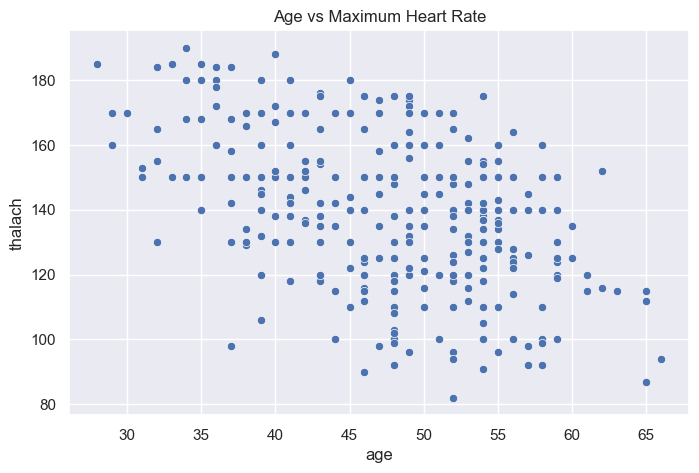

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='thalach', data=df)
plt.title("Age vs Maximum Heart Rate")
plt.show()

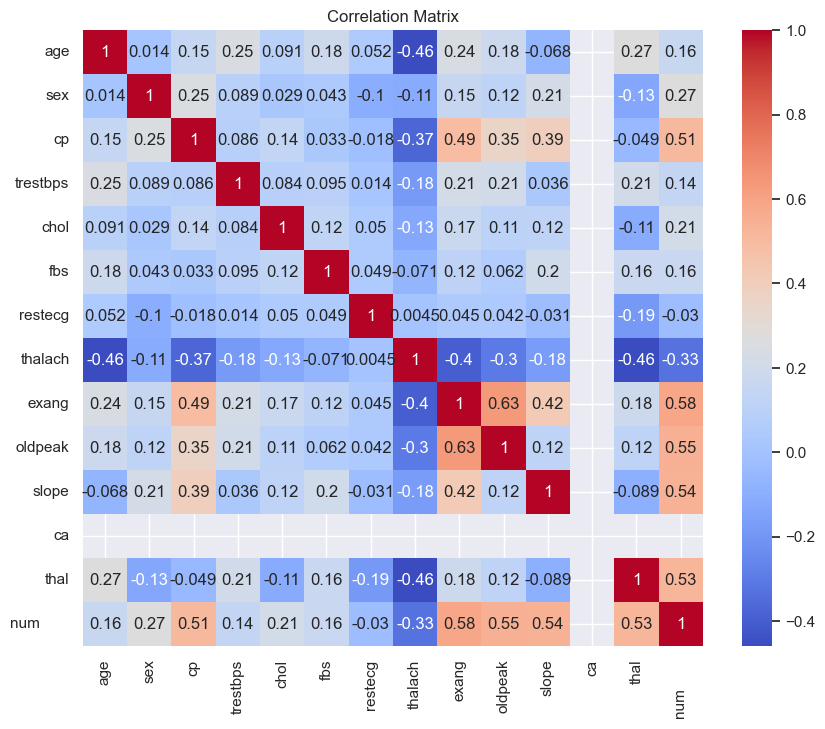

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()